<a href="https://colab.research.google.com/github/iqlore-collab/A-B-Testing-Chi-Squer/blob/main/GITHUB_ANALIZA_CHI_SQUERE_for_buttons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🇬🇧 A/B/C/D Experiment Analysis – Client
🎯 Objective

The goal of this analysis is to evaluate the performance of four homepage button variants tested on the Eniac website:

White “SHOP NOW”
Red “SHOP NOW”
White “SEE DEALS”
Red “SEE DEALS”

The primary business objective is to increase user engagement, measured through the Click-Through Rate (CTR) of the homepage button.

Additionally, the analysis aims to:

determine whether differences between variants are statistically significant,
identify the best-performing UI design,
understand how design choices (color and copy) affect user behavior.
📊 Input Data

The dataset comes from an A/B/C/D experiment conducted on the Eniac homepage.

Each CSV file (A, B, C, D) contains aggregated click-level interaction data.

Dataset structure:

Each file includes the following columns:

Element ID – unique identifier of UI elements
Tag name – HTML element type (e.g., a, div, h1)
Name – element label (e.g., Mac, iPhone, Accessories)
No. clicks – number of clicks per element
Visible? – whether the element was visible on the page
Snapshot information – metadata from the experiment snapshot
📌 Data scope
Total number of homepage visits (constant across variants): 50,061
Four experimental variants (A/B/C/D)
Aggregated click data per UI element
⚠️ Limitations
No user-level or session-level tracking
No navigation paths or funnel data
Missing metrics such as:
drop-off rate
homepage-return rate

Therefore, the analysis focuses on:

Click-Through Rate (CTR)
click distribution across UI elements
comparison of variants
🧪 Methodology

The following methods were used:

CTR as the primary metric:

CRT=
clicks
visits
/
visits
clicks
	​

Chi-square test (χ²) to assess:
whether click behavior differs across variants
Significance level:
α = 0.05
📈 Business Outcome

This analysis enables:

identification of the best-performing UI variant,
evaluation of whether UI changes significantly impact user behavior,
data-driven decision-making for homepage optimization and rollout strategy.

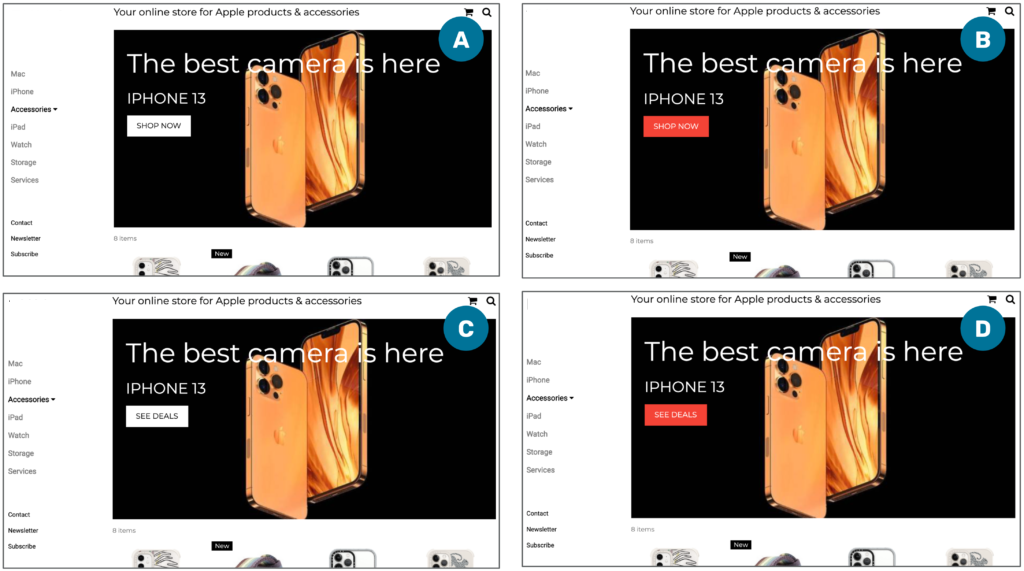

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns

In [4]:
# Ladowanie wszystkich plików do Colab
from google.colab import files
uploaded = files.upload()

Saving eniac_a.csv to eniac_a.csv
Saving eniac_b.csv to eniac_b.csv
Saving eniac_c.csv to eniac_c.csv
Saving eniac_d.csv to eniac_d.csv


In [5]:
# first load, to see what is in:
import pandas as pd

a = pd.read_csv("/content/eniac_a.csv")
b = pd.read_csv("/content/eniac_b.csv")
c = pd.read_csv("/content/eniac_c.csv")
d = pd.read_csv("/content/eniac_d.csv")

In [13]:
a.sample(10)

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
24,6,img,airpods,921,True,NaN
22,72,img,iphone13_cover,877,True,NaN
34,81,h4,Contact,298,True,NaN
41,54,a,We're hiring,41,True,NaN
37,119,input,Subject,201,True,NaN
9,15,a,AirTag,206,False,NaN
38,32,input,Message,195,True,NaN
51,8,a,Facebook,278,True,NaN
56,98,a,LinkedIn,284,True,NaN
15,17,a,Newsletter,56,True,NaN


In [14]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Element ID            57 non-null     int64 
 1   Tag name              57 non-null     object
 2   Name                  57 non-null     object
 3   No. clicks            57 non-null     int64 
 4   Visible?              57 non-null     bool  
 5   Snapshot information  2 non-null      object
dtypes: bool(1), int64(2), object(3)
memory usage: 2.4+ KB


#Null Hypothesis: all versions have the same CTR.
#Alternative Hypothesis: there is a difference in the CTR for the different versions.

In [9]:
import pandas as pd
import numpy as np
import scipy.stats as stats

# -----------------------------
# 1. LOAD DATA
# -----------------------------
a = pd.read_csv("/content/eniac_a.csv")
b = pd.read_csv("/content/eniac_b.csv")
c = pd.read_csv("/content/eniac_c.csv")
d = pd.read_csv("/content/eniac_d.csv")

data = {"A": a, "B": b, "C": c, "D": d}

# -----------------------------
# 2. ASSUMPTIONS FROM CASE STUDY
# -----------------------------
total_visits = 50061
alpha = 0.05

# -----------------------------
# 3. CTR CALCULATION (PRIMARY METRIC)
# -----------------------------
print("=== CTR BY VERSION ===\n")

results = {}

for name, df in data.items():
    clicks = df["No. clicks"].sum()
    ctr = clicks / total_visits

    results[name] = {
        "clicks": clicks,
        "ctr": ctr
    }

    print(f"Version {name}:")
    print(f"- Clicks: {clicks}")
    print(f"- CTR: {ctr:.4%}\n")

# -----------------------------
# 4. CONTINGENCY TABLE (FOR CHI-SQUARE)
# -----------------------------
table = np.array([
    [data["A"]["No. clicks"].sum(), total_visits - data["A"]["No. clicks"].sum()],
    [data["B"]["No. clicks"].sum(), total_visits - data["B"]["No. clicks"].sum()],
    [data["C"]["No. clicks"].sum(), total_visits - data["C"]["No. clicks"].sum()],
    [data["D"]["No. clicks"].sum(), total_visits - data["D"]["No. clicks"].sum()]
])

contingency = pd.DataFrame(
    table,
    index=["A", "B", "C", "D"],
    columns=["Clicked", "Not Clicked"]
)

# -----------------------------
# 5. CHI-SQUARE TEST
# -----------------------------
chi2, p, dof, expected = stats.chi2_contingency(contingency)

print("=== CHI-SQUARE TEST ===\n")
print(f"Chi2: {chi2:.4f}")
print(f"p-value: {p:.6f}")
print(f"dof: {dof}\n")

# -----------------------------
# 6. DROP-OFF RATE (PROXY)
# -----------------------------
# (brak eventów user-level → proxy only)

print("=== DROP-OFF RATE (PROXY LIMITATION) ===\n")
print("Note: True drop-off rate cannot be computed without session-level data.")
print("We only compute click engagement proxies.\n")

# -----------------------------
# 7. HOMEPAGE RETURN RATE (PROXY)
# -----------------------------
print("=== HOMEPAGE RETURN RATE (LIMITED VIEW) ===\n")
print("Note: Requires navigation/session tracking. Not available in this dataset.\n")

# -----------------------------
# 8. INTERPRETATION
# -----------------------------
print("=== INTERPRETATION ===\n")

if p < alpha:
    print("RESULT: Reject H0\n")
    print("- There is a statistically significant difference in CTR across versions.")
    print("- Button design (color + copy) impacts user engagement.\n")

    best = max(results, key=lambda x: results[x]["ctr"])

    print(f"WINNER: Version {best}")
    print(f"- CTR: {results[best]['ctr']:.4%}")

    print("\nBUSINESS CONCLUSION:")
    print("- Roll out winning variant after validating secondary metrics (drop-off & return rate).")

else:
    print("RESULT: Fail to reject H0\n")
    print("- No statistically significant difference in CTR.")
    print("- Observed differences are likely due to random variation.")
    print("\nBUSINESS CONCLUSION:")
    print("- No clear winner. Further experimentation recommended.")

# -----------------------------
# 9. RANKING
# -----------------------------
print("\n=== CTR RANKING ===\n")

ranking = pd.DataFrame({
    "Clicks": {k: v["clicks"] for k, v in results.items()},
    "CTR": {k: v["ctr"] for k, v in results.items()}
}).sort_values("CTR", ascending=False)

print(ranking)

=== CTR BY VERSION ===

Version A:
- Clicks: 23174
- CTR: 46.2915%

Version B:
- Clicks: 22407
- CTR: 44.7594%

Version C:
- Clicks: 23031
- CTR: 46.0059%

Version D:
- Clicks: 22743
- CTR: 45.4306%

=== CHI-SQUARE TEST ===

Chi2: 27.7736
p-value: 0.000004
dof: 3

=== DROP-OFF RATE (PROXY LIMITATION) ===

Note: True drop-off rate cannot be computed without session-level data.
We only compute click engagement proxies.

=== HOMEPAGE RETURN RATE (LIMITED VIEW) ===

Note: Requires navigation/session tracking. Not available in this dataset.

=== INTERPRETATION ===

RESULT: Reject H0

- There is a statistically significant difference in CTR across versions.
- Button design (color + copy) impacts user engagement.

WINNER: Version A
- CTR: 46.2915%

BUSINESS CONCLUSION:
- Roll out winning variant after validating secondary metrics (drop-off & return rate).

=== CTR RANKING ===

   Clicks       CTR
A   23174  0.462915
C   23031  0.460059
D   22743  0.454306
B   22407  0.447594


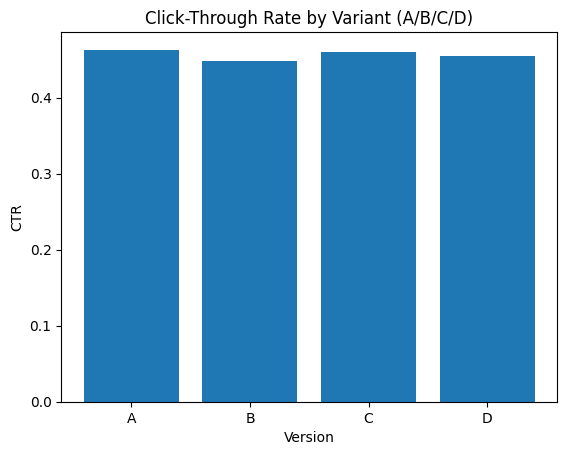

In [11]:
#CTR PLOT
import matplotlib.pyplot as plt
import pandas as pd

ctr_data = pd.DataFrame({
    "Version": ["A", "B", "C", "D"],
    "CTR": [
        wyniki["A"]["ctr"],
        wyniki["B"]["ctr"],
        wyniki["C"]["ctr"],
        wyniki["D"]["ctr"]
    ]
})

plt.figure()
plt.bar(ctr_data["Version"], ctr_data["CTR"])
plt.title("Click-Through Rate by Variant (A/B/C/D)")
plt.xlabel("Version")
plt.ylabel("CTR")
plt.show()

In [12]:
#EFFECT SIZE (CRAMÉR’S V) – PRO LEVEL STATISTICS
import numpy as np

chi2 = chi2  # z testu
n = contingency_table.values.sum()

cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

print("Cramér's V:", cramers_v)

if cramers_v < 0.1:
    print("Effect size: negligible")
elif cramers_v < 0.3:
    print("Effect size: small")
elif cramers_v < 0.5:
    print("Effect size: medium")
else:
    print("Effect size: large")

Cramér's V: 0.011777050227523574
Effect size: negligible


In [ ]:
#POLISH























🇵🇱 Analiza eksperymentu A/B/C/D – Eniac
🎯 Cel analizy

Celem tej analizy jest ocena skuteczności czterech wariantów przycisku na stronie głównej Eniac:

White “SHOP NOW”
Red “SHOP NOW”
White “SEE DEALS”
Red “SEE DEALS”

Głównym celem biznesowym jest zwiększenie zaangażowania użytkowników, mierzonego poprzez Click-Through Rate (CTR) przycisku na stronie głównej.

Dodatkowo analiza ma na celu:

sprawdzenie, czy różnice między wariantami są istotne statystycznie,
wybór najlepiej performującej wersji interfejsu,
zrozumienie wpływu designu (kolor + copy) na zachowanie użytkowników.
📊 Dane wejściowe

Dane pochodzą z eksperymentu A/B/C/D przeprowadzonego na stronie głównej Eniac.

Każdy wariant zawiera zagregowane dane o kliknięciach na elementy strony.

Struktura danych:

Każdy plik CSV (A, B, C, D) zawiera kolumny:

Element ID – identyfikator elementu UI
Tag name – typ elementu HTML (np. a, div, h1)
Name – nazwa elementu (np. Mac, iPhone, Accessories)
No. clicks – liczba kliknięć w dany element
Visible? – czy element był widoczny na stronie
Snapshot information – dodatkowe metadane z testu
📌 Zakres danych
Liczba wizyt na stronę (stała dla wszystkich wariantów): 50,061
Cztery warianty eksperymentu (A/B/C/D)
Agregowane kliknięcia per element UI
⚠️ Ograniczenia danych
Brak danych na poziomie użytkownika (user/session ID)
Brak pełnego tracking journey (brak ścieżek użytkownika)
Brak bezpośrednich metryk:
drop-off rate
homepage-return rate

Analiza skupia się więc głównie na:

CTR
rozkładzie kliknięć
porównaniu wariantów
🧪 Metodyka

W analizie zastosowano:

CTR jako główną metrykę:

CRT=

clicks
visits
/
visits
clicks
	​

Test chi-kwadrat (χ²) w celu sprawdzenia:
czy rozkład kliknięć różni się między wariantami
Poziom istotności:
α = 0.05
📈 Wynik biznesowy

Analiza pozwala:

określić, która wersja generuje najwyższe CTR,
ocenić, czy zmiany UI mają istotny wpływ na zachowanie użytkowników,
podjąć decyzję o wdrożeniu najlepszego wariantu.

In [10]:
import pandas as pd
import numpy as np
import scipy.stats as stats

# -----------------------------
# 1. WCZYTANIE DANYCH
# -----------------------------
a = pd.read_csv("/content/eniac_a.csv")
b = pd.read_csv("/content/eniac_b.csv")
c = pd.read_csv("/content/eniac_c.csv")
d = pd.read_csv("/content/eniac_d.csv")

dane = {"A": a, "B": b, "C": c, "D": d}

# -----------------------------
# 2. ZAŁOŻENIA Z CASE STUDY
# -----------------------------
wizyty = 50061
alpha = 0.05

# -----------------------------
# 3. CTR (GŁÓWNA METRYKA)
# -----------------------------
print("=== CTR DLA KAŻDEJ WERSJI ===\n")

wyniki = {}

for nazwa, df in dane.items():
    klikniecia = df["No. clicks"].sum()
    ctr = klikniecia / wizyty

    wyniki[nazwa] = {
        "klikniecia": klikniecia,
        "ctr": ctr
    }

    print(f"Wersja {nazwa}:")
    print(f"- Kliknięcia: {klikniecia}")
    print(f"- CTR: {ctr:.2%}\n")

# -----------------------------
# 4. TABELA KONTYNGENCJI (CHI-KWADRAT)
# -----------------------------
tabela = np.array([
    [dane["A"]["No. clicks"].sum(), wizyty - dane["A"]["No. clicks"].sum()],
    [dane["B"]["No. clicks"].sum(), wizyty - dane["B"]["No. clicks"].sum()],
    [dane["C"]["No. clicks"].sum(), wizyty - dane["C"]["No. clicks"].sum()],
    [dane["D"]["No. clicks"].sum(), wizyty - dane["D"]["No. clicks"].sum()]
])

contingency_table = pd.DataFrame(
    tabela,
    index=["A", "B", "C", "D"],
    columns=["Kliknięcia", "Brak kliknięć"]
)

print("=== TABELA KONTYNGENCJI ===\n")
print(contingency_table)

# -----------------------------
# 5. TEST CHI-KWADRAT
# -----------------------------
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("\n=== TEST CHI-KWADRAT ===\n")
print(f"Statystyka chi2: {chi2:.4f}")
print(f"p-value: {p:.6f}")
print(f"Stopnie swobody: {dof}\n")

# -----------------------------
# 6. INTERPRETACJA WYNIKÓW
# -----------------------------
print("=== INTERPRETACJA ===\n")

if p < alpha:
    print("WYNIK: Odrzucamy hipotezę zerową (H0)\n")

    print("- Istnieją istotne statystycznie różnice w CTR pomiędzy wersjami A, B, C i D.")
    print("- Design strony wpływa na zachowanie użytkowników (kliknięcia vs brak kliknięć).")
    print("- Co najmniej jedna wersja działa inaczej od pozostałych.\n")

    # najlepsza wersja
    ranking_ctr = {k: v["ctr"] for k, v in wyniki.items()}
    najlepsza = max(ranking_ctr, key=ranking_ctr.get)

    print("WNIOSKI BIZNESOWE:")
    print(f"- Najlepiej działa wersja: {najlepsza}")
    print(f"- CTR: {ranking_ctr[najlepsza]:.2%}")
    print("- Warto rozważyć wdrożenie tej wersji.")

else:
    print("WYNIK: Brak podstaw do odrzucenia H0\n")

    print("- Brak istotnych statystycznie różnic pomiędzy wersjami.")
    print("- Zmiany w designie nie wpływają istotnie na CTR.")
    print("- Obserwowane różnice mogą wynikać z losowości.\n")

    print("WNIOSKI BIZNESOWE:")
    print("- Brak wyraźnego zwycięzcy.")
    print("- Warto przeprowadzić kolejne testy lub zmienić hipotezę.")

# -----------------------------
# 7. DODATKOWE METRYKI (OGRANICZENIA DANYCH)
# -----------------------------
print("\n=== DODATKOWE METRYKI ===\n")

print("- Drop-off rate: nie można obliczyć bez danych sesyjnych (user-level tracking).")
print("- Homepage-return rate: wymaga danych o ścieżkach użytkowników.")
print("- Wniosek: dane pozwalają analizować tylko CTR i rozkład kliknięć.\n")

# -----------------------------
# 8. RANKING WERSJI
# -----------------------------
print("=== RANKING CTR ===\n")

ranking = pd.DataFrame({
    "Kliknięcia": {k: v["klikniecia"] for k, v in wyniki.items()},
    "CTR": {k: v["ctr"] for k, v in wyniki.items()}
}).sort_values("CTR", ascending=False)

print(ranking)

=== CTR DLA KAŻDEJ WERSJI ===

Wersja A:
- Kliknięcia: 23174
- CTR: 46.29%

Wersja B:
- Kliknięcia: 22407
- CTR: 44.76%

Wersja C:
- Kliknięcia: 23031
- CTR: 46.01%

Wersja D:
- Kliknięcia: 22743
- CTR: 45.43%

=== TABELA KONTYNGENCJI ===

   Kliknięcia  Brak kliknięć
A       23174          26887
B       22407          27654
C       23031          27030
D       22743          27318

=== TEST CHI-KWADRAT ===

Statystyka chi2: 27.7736
p-value: 0.000004
Stopnie swobody: 3

=== INTERPRETACJA ===

WYNIK: Odrzucamy hipotezę zerową (H0)

- Istnieją istotne statystycznie różnice w CTR pomiędzy wersjami A, B, C i D.
- Design strony wpływa na zachowanie użytkowników (kliknięcia vs brak kliknięć).
- Co najmniej jedna wersja działa inaczej od pozostałych.

WNIOSKI BIZNESOWE:
- Najlepiej działa wersja: A
- CTR: 46.29%
- Warto rozważyć wdrożenie tej wersji.

=== DODATKOWE METRYKI ===

- Drop-off rate: nie można obliczyć bez danych sesyjnych (user-level tracking).
- Homepage-return rate: wymaga danyc